# Challenge 2: Image Classification

## Hyperparameters

In [99]:
# --- Stochasticity -- 
SEED = 100

VALIDATION_SIZE = 0.2
IMAGE_SIZE = 512

# --- Model Parameters ---
MODEL_TYPE = 'ResNet50'
PRETRAINED = True
NUM_CLASSES = 10

# --- Training Hyperparameters ---
LEARNING_RATE = 0.0001
BATCH_SIZE = 64
EPOCHS = 300
PATIENCE = 50
OPTIMIZER = 'AdamW'

# Regularisation
DROPOUT_RATE = 0.2       
L1_LAMBDA = 0             
L2_LAMBDA = 0            

# Plot config
PLOT_FLAG = True

# --- Data Settings ---
WHITELIST_PATH = 'whitelist/super_clean_train_data.txt'

TRAIN_DATA_PATH = 'train_data'
TRAIN_IMAGES_CACHE_PATH = 'cache/train_images_cache.npy'
TRAIN_MASKS_CACHE_PATH = 'cache/train_masks_cache.npy'
TRAIN_MASKED_IMAGES_CACHE_PATH = 'cache/train_masked_images_cache.npy' 
TRAIN_LABEL_PATH = 'train_labels.csv'

TEST_DATA_PATH = 'test_data'
TEST_IMAGE_CACHE_PATH  = 'cache/test_images_cache.npy'
TEST_MASKS_CACHE_PATH = 'cache/test_masks_cache.npy'
TEST_MASKED_IMAGES_CACHE_PATH = 'cache/test_masked_images_cache.npy' 




## Module imports

In [100]:
import cplot

import os
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import csv
from sklearn.preprocessing import LabelEncoder



if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

CRITERION = nn.CrossEntropyLoss()



PyTorch version: 2.9.1+cu130
Device: cuda


## Image and Label Loader

In [101]:
def get_whitelisted_ids(whitelist_path):
    if not whitelist_path or not os.path.exists(whitelist_path):
        return None
    
    valid_ids = set()
    with open(whitelist_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split('_')
                if len(parts) >= 2:
                    valid_ids.add(parts[1].split('.')[0])
    return valid_ids

In [102]:
def load_labels_from_csv(csv_path, image_folder=None):
    print(f"Loading labels from {csv_path}...")
    
    # 1. Load the full CSV
    df = pd.read_csv(csv_path)
    
    # Clean IDs
    id_col = df.columns[0]
    label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(
        lambda x: x.split('_')[1].split('.')[0] if '_' in x else x
    )
    label_map = dict(zip(df['clean_id'], df[label_col]))

    # 2. IF an image folder is provided, Apply WHITELIST (Filter by files on disk)
    if image_folder:
        print(f"Applying WHITELIST from folder: {image_folder}")
        existing_files = set(os.listdir(image_folder))
        
        # Filter: Only keep IDs that exist as .png files
        valid_ids = []
        for f in existing_files:
            if f.startswith("img_") and f.endswith(".png"):
                valid_ids.append(f.split('_')[1].split('.')[0])
        
        # Sort to ensure alignment with load_images_from_folder
        sorted_ids = sorted(valid_ids)
        
        # Build the aligned label list
        final_labels = []
        for uid in sorted_ids:
            if uid in label_map:
                final_labels.append(label_map[uid])
            else:
                print(f"Warning: Image {uid} is on disk but missing from CSV")
                
        print(f"Labels reduced from {len(df)} (CSV) to {len(final_labels)} (Disk Whitelist)")
        return np.array(final_labels)

    # 3. Fallback (Dangerous: Loads all CSV rows)
    print("WARNING: No image folder provided. Loading ALL labels from CSV (No Whitelist).")
    sorted_ids = sorted(label_map.keys())
    return np.array([label_map[uid] for uid in sorted_ids])

In [103]:
def load_labels_aligned(csv_path, filtered_ids_list):

    print(f"Loading labels for {len(filtered_ids_list)} filtered images...")
    
    # 1. Load the CSV
    df = pd.read_csv(csv_path)
    
    # 2. Clean CSV IDs (standardize format)
    id_col = df.columns[0]
    label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(
        lambda x: x.split('_')[1].split('.')[0] if '_' in x else x
    )
    
    # 3. Create a dictionary map {id: label}
    label_map = dict(zip(df['clean_id'], df[label_col]))
    
    # 4. Build the final label list in the EXACT order of the provided IDs
    final_labels = []
    for uid in filtered_ids_list:
        if uid in label_map:
            final_labels.append(label_map[uid])
        else:
            print(f"Warning: Image ID {uid} exists in data but is missing in CSV!")
            raise ValueError(f"Label missing for ID {uid}")
            
    return np.array(final_labels)

In [104]:
# %%
def load_images_and_filter(folder, cache_path_images, cache_path_masks, cache_masked_images_path, whitelist_path=None):
    
    # 1. GET IDS FROM FOLDER
    all_filenames = [f for f in os.listdir(folder) if f.startswith('img_') and f.endswith('.png')]
    sorted_ids = sorted([f.split('_')[1].split('.')[0] for f in all_filenames])
    
    # 2. LOAD FULL CACHE (Using Memory Mapping)
    if (os.path.exists(cache_path_images) and 
        os.path.exists(cache_path_masks) and
        os.path.exists(cache_masked_images_path)):
        
        print(f"Loading full cache (Memory Mapped)...")
        # mmap_mode='r' keeps the array on disk. It uses almost 0 RAM.
        full_raw = np.load(cache_path_images, mmap_mode='r') 
        full_masks = np.load(cache_path_masks, mmap_mode='r')
        full_masked = np.load(cache_masked_images_path, mmap_mode='r')
        
    else:
        # Cache creation (Only happens if cache is missing)
        print(f"Cache missing. Processing from {folder}...")
        raw_list, mask_list, masked_list = [], [], []

        for image_id in sorted_ids:
            img_path = os.path.join(folder, f"img_{image_id}.png")
            mask_path = os.path.join(folder, f"mask_{image_id}.png")
            
            if not os.path.exists(mask_path): continue

            # Load & Process
            img = cv2.imread(img_path)
            img = (img / 255.0).astype(np.float32)[..., ::-1] 
            
            mask_img = cv2.imread(mask_path)
            mask_img = (mask_img / 255.0).astype(np.float32)[..., ::-1]

            # Padding
            h, w = img.shape[:2]
            if h > w:
                delta_w = h - w
                top, bottom, left, right = 0, 0, delta_w // 2, delta_w - (delta_w // 2)
            elif w > h:
                delta_h = w - h
                top, bottom, left, right = delta_h // 2, delta_h - (delta_h // 2), 0, 0
            else:
                top, bottom, left, right = 0, 0, 0, 0

            img_padded = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0,0,0])
            mask_padded = cv2.copyMakeBorder(mask_img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0,0,0])

            # Resize
            img_resized = cv2.resize(img_padded, (IMAGE_SIZE, IMAGE_SIZE))
            mask_resized = cv2.resize(mask_padded, (IMAGE_SIZE, IMAGE_SIZE))
            
            raw_list.append(img_resized)
            mask_list.append(mask_resized)
            masked_list.append(img_resized * mask_resized)

        full_raw = np.array(raw_list)
        full_masks = np.array(mask_list)
        full_masked = np.array(masked_list)
        
        os.makedirs(os.path.dirname(cache_path_images), exist_ok=True)
        np.save(cache_path_images, full_raw)
        np.save(cache_path_masks, full_masks)
        np.save(cache_masked_images_path, full_masked)
        print(f"Cache created with {len(full_raw)} samples.")

    # 3. FILTER (Apply Whitelist)
    if not whitelist_path:
        # For Test data (no whitelist), we return the mmap object directly.
        # This allows you to use the data without crashing RAM.
        return full_raw, full_masks, full_masked, sorted_ids

    print(f"Filtering with whitelist: {whitelist_path}")
    whitelist_set = get_whitelisted_ids(whitelist_path)
    
    indices_to_keep = []
    filtered_ids = []
    
    for index, img_id in enumerate(sorted_ids):
        if img_id in whitelist_set:
            indices_to_keep.append(index)
            filtered_ids.append(img_id)

    # CRITICAL: This line effectively copies ONLY the filtered images into RAM
    # The rest of the huge dataset stays on the hard drive.
    return (np.array(full_raw[indices_to_keep]), 
            np.array(full_masks[indices_to_keep]), 
            np.array(full_masked[indices_to_keep]), 
            filtered_ids)

In [105]:
def get_sorted_filenames(folder):
    ids = set()
    for f in os.listdir(folder):
        if f.startswith("img_") and f.endswith(".png"):
            ids.add(f.split('_')[1].split('.')[0])
    return [f"img_{i}.png" for i in sorted(list(ids))]

Loading full cache (Memory Mapped)...
Filtering with whitelist: whitelist/super_clean_train_data.txt
Loading labels for 748 filtered images...
Loading full cache (Memory Mapped)...
Loaded 748 images
Loaded 748 masks
Loaded 748 masked images for training
Loaded 748 labels for training


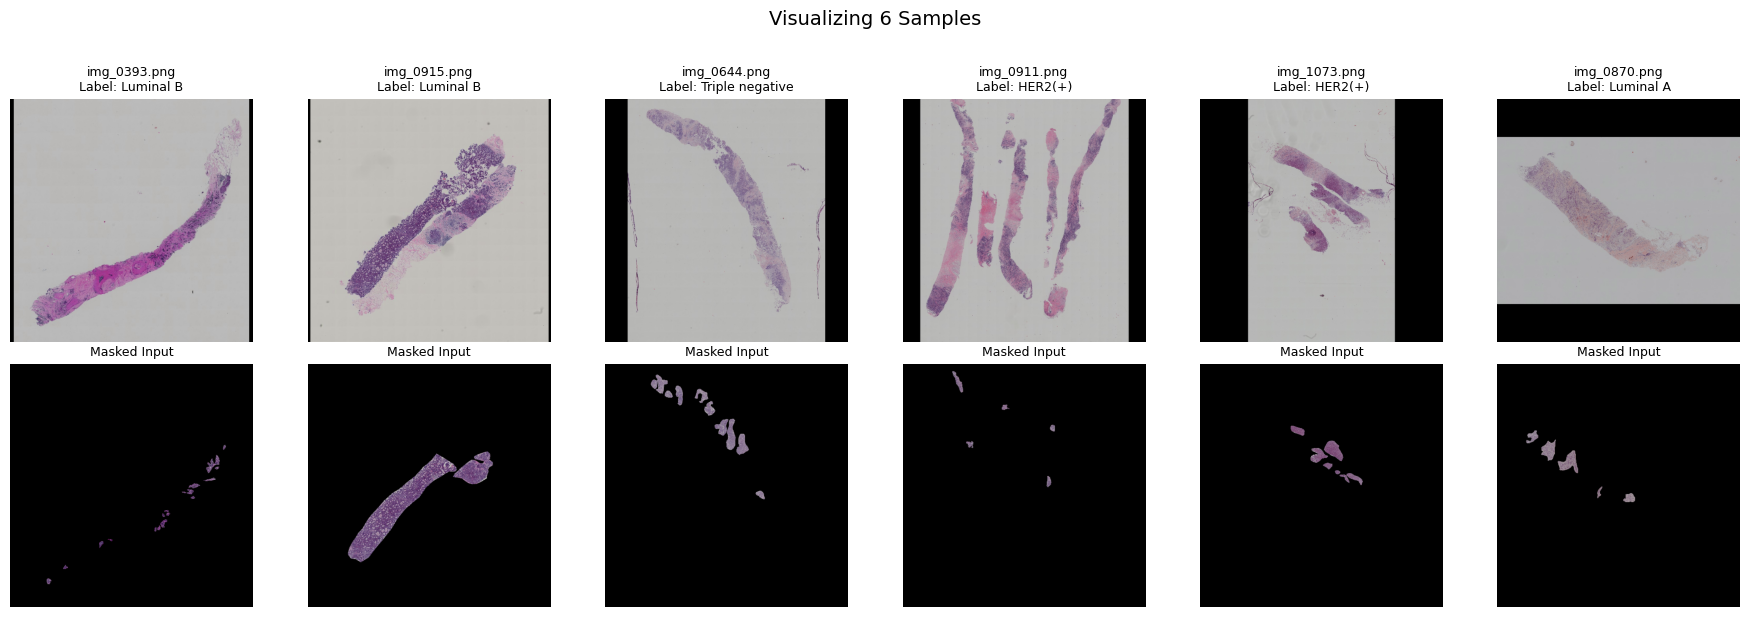

In [106]:
# Load images and labels
raw_train_images, train_masks, train_images_masked, train_ids = load_images_and_filter(
    TRAIN_DATA_PATH, 
    TRAIN_IMAGES_CACHE_PATH, 
    TRAIN_MASKS_CACHE_PATH,
    TRAIN_MASKED_IMAGES_CACHE_PATH,
    whitelist_path=WHITELIST_PATH 
)

train_labels = load_labels_aligned(TRAIN_LABEL_PATH, train_ids)

# Load Test Data
raw_test_images, test_masks, test_images_masked, test_ids = load_images_and_filter(
    TEST_DATA_PATH, 
    TEST_IMAGE_CACHE_PATH, 
    TEST_MASKS_CACHE_PATH,
    TEST_MASKED_IMAGES_CACHE_PATH,
    whitelist_path=None 
)
print(f"Loaded {len(raw_train_images)} images")
print(f"Loaded {len(train_masks)} masks")
print(f"Loaded {len(train_images_masked)} masked images for training")
print(f"Loaded {len(train_labels)} labels for training")

# Plotting
if PLOT_FLAG: 
    train_filenames_aligned = [f"img_{uid}.png" for uid in train_ids]
    cplot.visualize_image_components(raw_train_images, train_masks, train_labels, filenames=train_filenames_aligned, num_samples=6)

## Dataloader creation

In [107]:
# %% [markdown]
# ## Dataloader creation

# %%
def make_loader(ds, batch_size, shuffle, drop_last):
    # Robust worker detection
    if os.name == 'nt': # Windows
        num_workers = 0 
    else: 
        num_workers = min(8, os.cpu_count() or 2)
        
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0), 
    )

def preprocess_inputs(images):
    # Input shape: (N, IMAGE_SIZE, IMAGE_SIZE, 3)
    # Output shape: (N, 3, IMAGE_SIZE, IMAGE_SIZE)
    tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2)
    return tensor

# --- Setup Data ---
# 1. Use the filtered images we loaded previously
X_input = train_images_masked
train_labels_aligned = train_labels 

# --- 3. Safety Check ---
print(f"Images: {len(X_input)} | Labels: {len(train_labels_aligned)}")
if len(X_input) != len(train_labels_aligned):
    raise ValueError(f"Mismatch! Images: {len(X_input)}, Labels: {len(train_labels_aligned)}")

# --- 4. Prepare Tensor (Inputs) ---
X_tensor = preprocess_inputs(X_input)

# --- 5. Prepare Tensor (Labels) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_labels_aligned)
Y_tensor = torch.from_numpy(y_encoded).long()

print(f"X Shape: {X_tensor.shape}")  # Should be (748, 3, 512, 512)
print(f"Y Shape: {Y_tensor.shape}")  # Should be (748,)

# --- 6. Split and Create Loaders ---
indices = np.arange(len(X_tensor))
train_idx, val_idx = train_test_split(
    indices, 
    test_size=VALIDATION_SIZE, 
    random_state=SEED, 
    stratify=y_encoded
)

train_ds = TensorDataset(X_tensor[train_idx], Y_tensor[train_idx])
val_ds   = TensorDataset(X_tensor[val_idx],   Y_tensor[val_idx])

# Create loaders
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# --- Summary ---
print("-" * 30)
print(f"Train Shape: {train_ds[0][0].shape} | Samples: {len(train_ds)}")
print(f"Val Shape:   {val_ds[0][0].shape} | Samples: {len(val_ds)}")
print("-" * 30)
for i, name in enumerate(label_encoder.classes_):
    print(f"  {i}: {name}")
print("-" * 30)

Images: 748 | Labels: 748
X Shape: torch.Size([748, 3, 512, 512])
Y Shape: torch.Size([748])
------------------------------
Train Shape: torch.Size([3, 512, 512]) | Samples: 598
Val Shape:   torch.Size([3, 512, 512]) | Samples: 150
------------------------------
  0: HER2(+)
  1: Luminal A
  2: Luminal B
  3: Triple negative
------------------------------


## CNN Model

### Model Architecture

In [108]:
class SimpleCNN(nn.Module):

    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

### Training epoch

In [109]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):

    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

### Validating epoch

In [110]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [111]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)



        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

### Training

In [112]:
# Instantiate CNN model and move to computing device (CPU/GPU)
input_shape = train_ds[0][0].shape 
num_classes = len(label_encoder.classes_)
vanilla_model = SimpleCNN(
    input_shape,
    num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

# Display model architecture summary
#summary(vanilla_model, input_size=input_shape)
#model_graph = draw_graph(vanilla_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True)
#model_graph.visual_graph

# Set up TensorBoard logging and save model architecture
experiment_name = "vanilla_cnn"
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(vanilla_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [113]:
# Train model and track training history
vanilla_model, vanilla_history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=CRITERION,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="vanilla_cnn",
    patience=PATIENCE
)

# Update best model if current performance is superior
if vanilla_history['val_f1'][-1] > best_performance:
    best_model = vanilla_model
    best_performance = vanilla_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(vanilla_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 300 epochs...
Epoch   1/300 | Train: Loss=1.3315, F1 Score=0.2057 | Val: Loss=1.3085, F1 Score=0.1967
Epoch   2/300 | Train: Loss=1.3062, F1 Score=0.1994 | Val: Loss=1.3040, F1 Score=0.1967
Epoch   3/300 | Train: Loss=1.2951, F1 Score=0.1994 | Val: Loss=1.3038, F1 Score=0.1967
Epoch   4/300 | Train: Loss=1.2907, F1 Score=0.1994 | Val: Loss=1.3009, F1 Score=0.1967
Epoch   5/300 | Train: Loss=1.2656, F1 Score=0.2030 | Val: Loss=1.2961, F1 Score=0.2576
Epoch   6/300 | Train: Loss=1.2379, F1 Score=0.3636 | Val: Loss=1.2990, F1 Score=0.3076
Epoch   7/300 | Train: Loss=1.1578, F1 Score=0.5053 | Val: Loss=1.3162, F1 Score=0.3354
Epoch   8/300 | Train: Loss=1.0720, F1 Score=0.4663 | Val: Loss=1.4111, F1 Score=0.3648
Epoch   9/300 | Train: Loss=0.9740, F1 Score=0.5862 | Val: Loss=1.5327, F1 Score=0.3627
Epoch  10/300 | Train: Loss=0.8717, F1 Score=0.6434 | Val: Loss=1.5766, F1 Score=0.3637
Epoch  11/300 | Train: Loss=0.7504, F1 Score=0.7034 | Val: Loss=1.8271, F1 Score=0.3278
Epoch  12

#### Plot Results

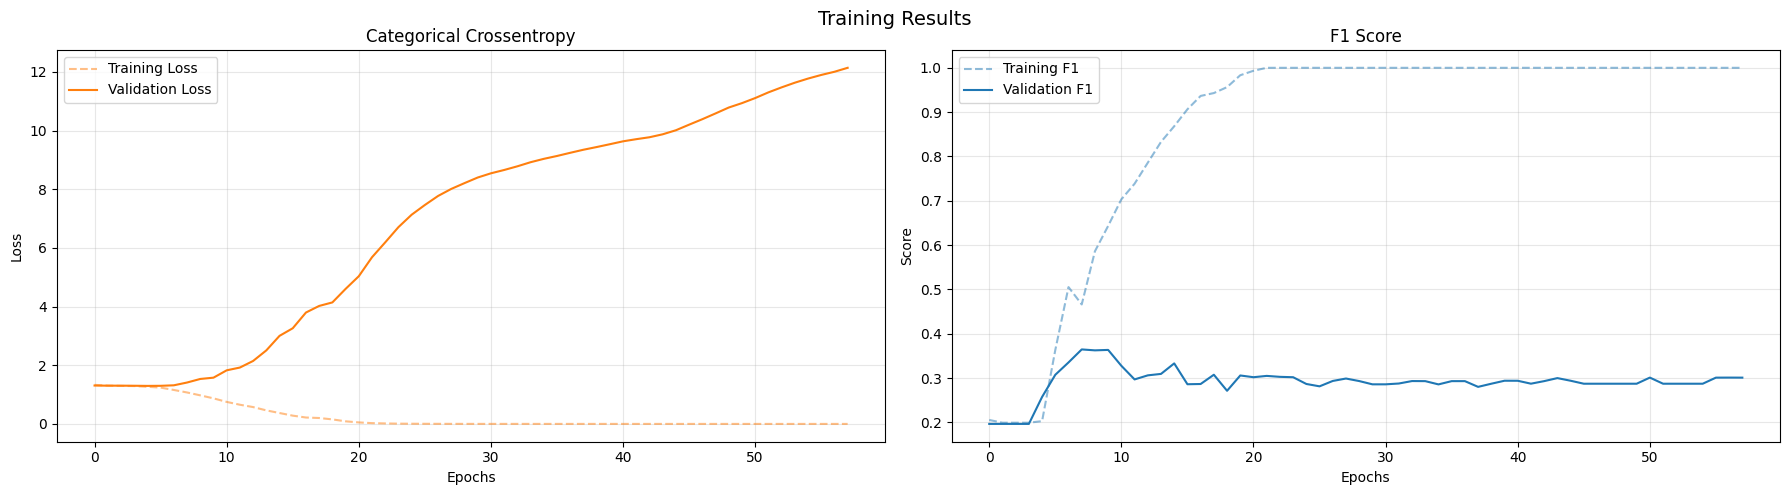

In [114]:
if PLOT_FLAG:
    cplot.plot_training_history(vanilla_history, title=f"Training Results")

## Test Prediction

In [115]:
def get_predictions(model, loader, device):
    print(f"--- Starting Inference on {len(loader.dataset)} Samples ---")
    model.eval()
    all_predictions = []
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            # Handle both (inputs, labels) or just (inputs) loaders
            inputs = batch[0].to(device)
            
            # Forward pass using mixed precision
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
            
            # Get class indices
            preds = logits.argmax(dim=1).cpu().numpy()
            all_predictions.extend(preds)
            
    print("Inference complete.")
    return np.array(all_predictions)

In [116]:

def create_submission_csv(predictions, filenames, encoder, output_csv="submission.csv"):

    if len(predictions) != len(filenames):
        raise ValueError(f"Mismatch: {len(predictions)} predictions vs {len(filenames)} filenames")

    print(f"Decoding {len(predictions)} labels...")
    predicted_labels = encoder.inverse_transform(predictions)
    
    submission_df = pd.DataFrame({
        'sample_index': filenames,
        'label': predicted_labels
    })
    
    submission_df.to_csv(output_csv, index=False)
    print(f"Saved submission to '{output_csv}'")
    print(submission_df.head())
    
    return submission_df

In [117]:

# --- Prepare Test Data ---
X_test_tensor = preprocess_inputs(test_images_masked) 
test_ds = TensorDataset(X_test_tensor)
test_filenames = get_sorted_filenames(TEST_DATA_PATH)

# --- Create DataLoaders ---
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Test Shape:  {test_ds[0][0].shape} | Samples: {len(test_ds)}")

# --- Check for best model ---
if 'best_model' not in locals() or best_model is None:
    print("Best model not found, using last trained model state.")
    best_model = vanilla_model

# 1. Run Predictions
raw_predictions = get_predictions(best_model, test_loader, device)


# 2. Generate CSV
_ = create_submission_csv(
    predictions=raw_predictions,
    filenames=test_filenames,
    encoder=label_encoder,
    output_csv="submission.csv"
)

C:\Users\reluc\AppData\Local\Temp\ipykernel_19896\2026355781.py:25: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2)


Test Shape:  torch.Size([3, 512, 512]) | Samples: 954
--- Starting Inference on 954 Samples ---
Inference complete.
Decoding 954 labels...
Saved submission to 'submission.csv'
   sample_index      label
0  img_0000.png  Luminal A
1  img_0001.png  Luminal A
2  img_0002.png  Luminal A
3  img_0003.png  Luminal A
4  img_0004.png  Luminal A
